# Transformer based compression research project toolkit

This is a notebook with many numerical examples of concepts found in *Elements of Information Theory*

These functions may be useful in future experiments exploring universal source coding and transformer based coding. For now, they are used as an educational tool to reinforce concepts in the book.

# Reserach objectives

We train a simple GPT based transformer to try to outperform classical predictive models in a compression context. For our classical baseline, we use the laplace estimator. Probabilities from the laplace estimator are encoded and showcase compression performance without needing to implement the compression schemes ourselves. 

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from math import comb 
from itertools import combinations 
import pickle

In [2]:
# Concepts: basic entropy calculations

x = [0, 0, 1, 1, 1, 2]

def convert_sample_to_pmf(sample):
    values, counts = np.unique(sample, return_counts=True)
    probs = counts/counts.sum()
    return dict(zip(values, probs))

def clean_pmf(pmf):
    return {k: v for k, v in pmf.items() if v > 0.0}

def generate_bin_pmf():
    p = np.random.rand()
    dict_out = {
        0: p,
        1: 1-p
    }
    return dict_out

def iid_generate(p_dict, N):
    p0 = p_dict[0]
    p1 = p_dict[1]
    return np.random.choice([0,1], size=N, p=[p0, p1])

def exact_binary_sample(p, N):
    count0 = int(round(p[0] * N))
    count1 = N - count0  

    samples = np.array([0]*count0 + [1]*count1)
    np.random.shuffle(samples)

    return samples

def entropy_calc(pmf):
    pmf = clean_pmf(pmf)
    pmf_array = np.asarray(list(pmf.values()))
    return -np.sum(pmf_array * np.log2(pmf_array))


In [5]:
# Concept: grouping values together means that entropy cannot increase

X = [1, 2, 3, 4, 5, 6, 7, 8]
X_pmf = convert_sample_to_pmf(X)

def coarsening_func(pmf_dict):
    pmf_fdict = {}
    for k, v in pmf_dict.items():
        if k in [1]:
            new_key = 'A'
        else:
            new_key = 'B'
        pmf_fdict[new_key] = pmf_fdict.get(new_key, 0) + v
    return pmf_fdict

print(f'H(f(X)) = {entropy_calc(coarsening_func(X_pmf))} is less than H(X) = {entropy_calc(X_pmf)}')

H(f(X)) = 0.5435644431995964 is less than H(X) = 3.0


In [6]:
# Concepts: Conditional probability, chain rule

p_joint = {
    (0,0): 0.1,
    (0,1): 0.2,
    (0,2): 0.1,
    (1,0): 0.05,
    (1,1): 0.3,
    (1,2): 0.25
}

def p_X_marg(p_joint):
    p_X = {}
    for (x, y), p in p_joint.items():
        p_X[x] = p_X.get(x, 0) + p
    return p_X

def p_Y_marg(p_joint):
    p_Y = {}
    for (x, y), p in p_joint.items():
        p_Y[y] = p_Y.get(y, 0) + p
    return p_Y

def p_X_given_Y_convert(p_joint):
    p_Y = p_Y_marg(p_joint)
    p_X_given_Y = {}
    for (x, y), p in p_joint.items():
        cond = p / p_Y[y]
        p_X_given_Y[(x, y)] = cond
    return p_X_given_Y

def p_Y_given_X_convert(p_joint):
    p_X = p_X_marg(p_joint)
    p_Y_given_X = {}
    for (x, y), p in p_joint.items():
        cond = p / p_X[x]
        p_Y_given_X[(x, y)] = cond
    return p_Y_given_X

def cond_entropy_Y_given_X(p_joint):
    h_Y_X = 0
    p_X = p_X_marg(p_joint)
    for x in p_X:
        cond_pmf = {}
        for (x2, y), p in p_joint.items():
            if x2 == x:
                cond_pmf[y] = p / p_X[x]
        slice_entropy = entropy_calc(cond_pmf) 
        h_Y_X += p_X[x] * slice_entropy
    return h_Y_X

def cond_entropy_X_given_Y(p_joint):
    h_X_Y = 0
    p_Y = p_Y_marg(p_joint)
    for y in p_Y:
        cond_pmf = {}
        for (x, y2), p in p_joint.items():
            if y2 == y:
                cond_pmf[x] = p / p_Y[y]
        slice_entropy = entropy_calc(cond_pmf) 
        h_X_Y += p_Y[y] * slice_entropy
    return h_X_Y

# implementing chain rule checks
# verify H(X,Y) = H(X|Y) + H(Y)

H_XY = entropy_calc(p_joint)
H_Y_given_X = cond_entropy_Y_given_X(p_joint)
H_X = entropy_calc(p_X_marg(p_joint))

print(H_XY, H_Y_given_X + H_X)
print(f'error: {H_XY - (H_Y_given_X + H_X)}')


2.365957320949175 2.3659573209491747
error: 4.440892098500626e-16


## Jensen's inequality + concavity

The following code implements a concavity check of the entropy calc function for the binary case.  

In [7]:
# implement something like f(lambda * x1 + (1-lambda)*x2) <= lambda * f(x1) + (1-lambda) * f(x2)

def numerical_jansen_check(p, q, func):
    lams = np.linspace(0, 1, 50)
    results = []
    for lam in lams:
        m = {k: lam*p[k] + (1-lam)*q[k] for k in p.keys()}
        lhs = func(m)
        rhs = lam*func(p) + (1-lam)*func(q)
        results.append(lhs >= rhs)
    return all(results) 

pmf1 = generate_bin_pmf()
pmf2 = generate_bin_pmf()

# Verify the concavity of entropy function
entropy_concave_check = numerical_jansen_check(pmf1, pmf2, entropy_calc)
print(entropy_concave_check)


True


### Kullback-Leibler divergence
In the following python exercises we develop functions to calculate the KL divergence of two binary distributions 

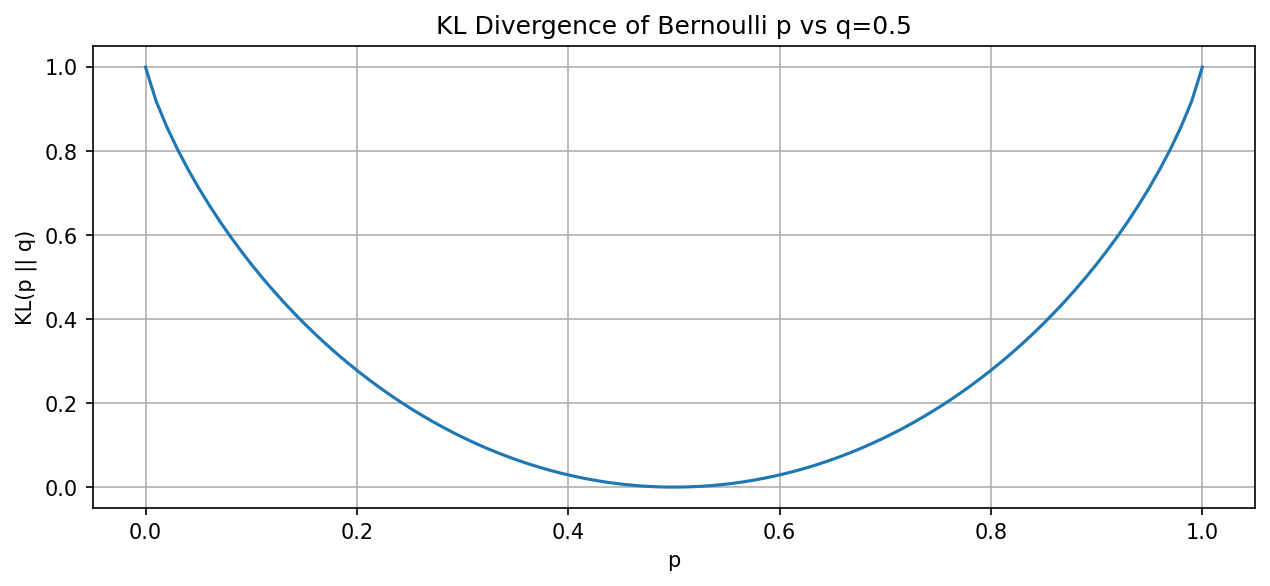

In [8]:
def kl_div(p, q):
    p_val = np.asarray(list(p.values()))
    q_val = np.asarray(list(q.values()))
    mask = p_val > 0
    p_val = p_val[mask]
    q_val = q_val[mask]
    result = np.sum(p_val * np.log2(p_val/q_val))
    return result

probability = np.linspace(0, 1, 100)


kl_values = []

for prob in probability:
    p = {0: prob, 1:1-prob}
    q = {0: 0.5, 1:0.5}
    kl_values.append(kl_div(p, q))

plt.figure(figsize=(10, 4), dpi=150)
plt.plot(probability, kl_values)
plt.xlabel("p")
plt.ylabel("KL(p || q)")
plt.title("KL Divergence of Bernoulli p vs q=0.5")
plt.grid(True)
plt.show()




## Shannon average code length calculation for realizable codes

When code lengths are expected to be integers which are an unescapable reality in real compression schemes, the word lengths must be rounded up to the nearest integer. 

Therefore, we calculate $ L = \sum_i p_i \, l_i $ using $ l_i = \lceil \log_2 \frac{1}{p_i} \rceil $

In [ ]:

def shannon_average_code_length_calc_integer(pmf):
    output = 0
    for digit in pmf.keys():
        output += pmf[digit] * np.ceil(-np.log2(pmf[digit]))
    return output

p = generate_bin_pmf()
L = shannon_average_code_length_calc_integer(p)
H = entropy_calc(p)

print(f'probability: {p}')
print(f'Shannon_average_code_length_integer: {L}')
print(f'Entropy: {H}')
print(f'Test for if H < L < H+1: {H < L < H + 1}')

## Kraft inequality 
Below we implement a Kraft inequality verification function

We are implementing the following inequality:

$ \sum_{x \in \mathcal{X}} D^{-l(x)} \le 1 $



In [ ]:
def kraft_inequality_verify(pmf):
    pmf = np.asarray(list(pmf.values()))
    return np.sum(2 ** -(np.ceil(-np.log2(pmf)))) <= 1


### Universal source coding

We start to get into the meat of what we're really here for: getting average code lengths using what we know about universal source coding!

The Csiszar-Korner universal code length calculation comes from the Elements of Information theory book in chapter 13 (eq. 13.32):

$
\ell(x^n) \le \log_2 (n + 1) + \log_2 \binom{n}{k} + 2
$




In [9]:
seq_test = exact_binary_sample(generate_bin_pmf(), 1000) 

pmf_find = convert_sample_to_pmf(seq_test)

def csiszar_korner_universal_code_length(seq):
    n = len(seq)
    k = np.sum(seq)
    ltype = np.ceil(np.log2(n+1)) 
    if k == 0 or k == n:
        lseq = 0
    else:
        lseq = np.ceil(np.log2(comb(n, k)))
    return ltype + lseq 

def expected_ck(seq, n):
    total = 0
    blocks = 0

    for i in range(0, len(seq), n):
        block = seq[i:i+n].tolist()
        if len(block) < n:
            block += [0]*(n - len(block))
        b_len = csiszar_korner_universal_code_length(block)
        total += b_len
        blocks += n

    return total / blocks
        

## Encoding algorithm

The universal source coding calculation above only calculates the code length bit size

We will implement a type based universal source compressor to more concretely and empirically match our theoretical length calculation 

In [10]:

def int_to_bits(n, length):
    return [int(b) for b in bin(n)[2:].zfill(length)]

def lex_rank(seq):
    rank = 0
    ones_left = sum(seq)
    k = sum(seq)
    n = len(seq)
    bit_length = int(np.ceil(np.log2(comb(n, k))))

    if ones_left == 0:
        return int_to_bits(rank, bit_length)

    for i, bit in enumerate(seq):
        if bit == 1:
            rank += comb(n - i - 1, ones_left)
            ones_left -= 1
    return int_to_bits(rank, bit_length)


def type_encode(block):
    n = len(block)
    k = sum(block)

    bit_length_k = np.ceil(np.log2(n + 1))
    k_bits = int_to_bits(int(k), int(bit_length_k))
    return k_bits

def full_encode(full_seq, n):
    blocks = []
    full_array = []

    for i in range(0, len(full_seq), n):
        block = full_seq[i:i+n].tolist()
        if len(block) < n:
            block += [0]*(n - len(block))
        blocks.append(block)

    for block in blocks:
        typ = type_encode(block)
        idx = lex_rank(block)

        full_array.append(typ)
        full_array.append(idx)

    flat_stream = [bit for bits in full_array for bit in list(bits)]
    return flat_stream 


block_size = 30
compress_seq = iid_generate(generate_bin_pmf(), 10000) 
generated_p = convert_sample_to_pmf(compress_seq)
p = generated_p[1]
bps_empirical = len(full_encode(compress_seq, block_size))/len(compress_seq)
bps_shanon_real = shannon_average_code_length_calc_integer(generated_p)
bps_ex_ck = expected_ck(compress_seq, block_size)
bps_lower_limit = entropy_calc(generated_p)

print(f'Calculating with p = {p}')
print(f'bps_empirical: {bps_empirical}')
print(f'bps_ex_ck {bps_ex_ck}')
print(f'bps_shanon_real {bps_shanon_real}')
print(f'bps_lower_limit {bps_lower_limit}')







NameError: name 'shannon_average_code_length_calc_integer' is not defined

## Encoding Algorithm 2

We develop another algorithm for universal source coding. This algorithm will simply sequentially calculate the bit length sequentially

In [29]:
def sequential_universal_source_coding(seq, p_array = None):
    total_bits = 0
    k = 0
    i = 0

    for bit in seq:
        if p_array is not None:
            p1 = p_array[i]
        else:
            p1 = (k+1) / (i+2)
        p0 = 1-p1

        if bit == 1:
            total_bits += -np.log2(p1)
        else:
            total_bits += -np.log2(p0)
        k += bit
        i += 1

    bits_per_symbol = total_bits / len(seq)
    return bits_per_symbol


bps_sequential = sequential_universal_source_coding(compress_seq) 
bps_lower_limit = entropy_calc(generated_p)

print(f'Calculating with p = {p}')
print(f'bps_sequential: {bps_sequential}')
print(f'bps_ck_empirical: {bps_empirical}')
print(f'bps_lower_limit {bps_lower_limit}')


half_log_n = 1/2 * np.log2(len(compress_seq)) / len(compress_seq)
two_stage_cost = bps_empirical - bps_sequential

print(f'(1/2)*logn = {half_log_n} actual two stage compression cost: {two_stage_cost}')



Calculating with p = 0.6187
bps_sequential: 0.9595910054128426
bps_ck_empirical: 1.0255
bps_lower_limit 0.9589549995868245
(1/2)*logn = 0.0006643856189774724 actual two stage compression cost: 0.06590899458715749


# N sweep

This figure examines the relationship between bitlength and size of the sequence 

Before doing that let me ask:
- How should we perform a sweep when dealing with probabilities
- I want to change N or sequence length and experiment with how that changes compression rates. Each experiment will have different results though, so I need guidance on how to run probabalistic experiments

True entropy: 0.8812908992306927
N=10  mean=0.9316236620038716  std=0.2095479500345914  gap=0.050332762773178885
N=50  mean=0.9185797616197273  std=0.09044277497934454  gap=0.037288862389034616
N=100  mean=0.9015548393303635  std=0.05259543941291415  gap=0.020263940099670807
N=500  mean=0.8886395295780127  std=0.0265884946010264  gap=0.007348630347320029
N=1000  mean=0.886171252605157  std=0.016343756161980406  gap=0.004880353374464241
N=5000  mean=0.881549707412602  std=0.006928204116597285  gap=0.0002588081819092647
N=10000  mean=0.8812758947055117  std=0.005532720916280365  gap=-1.5004525180994932e-05


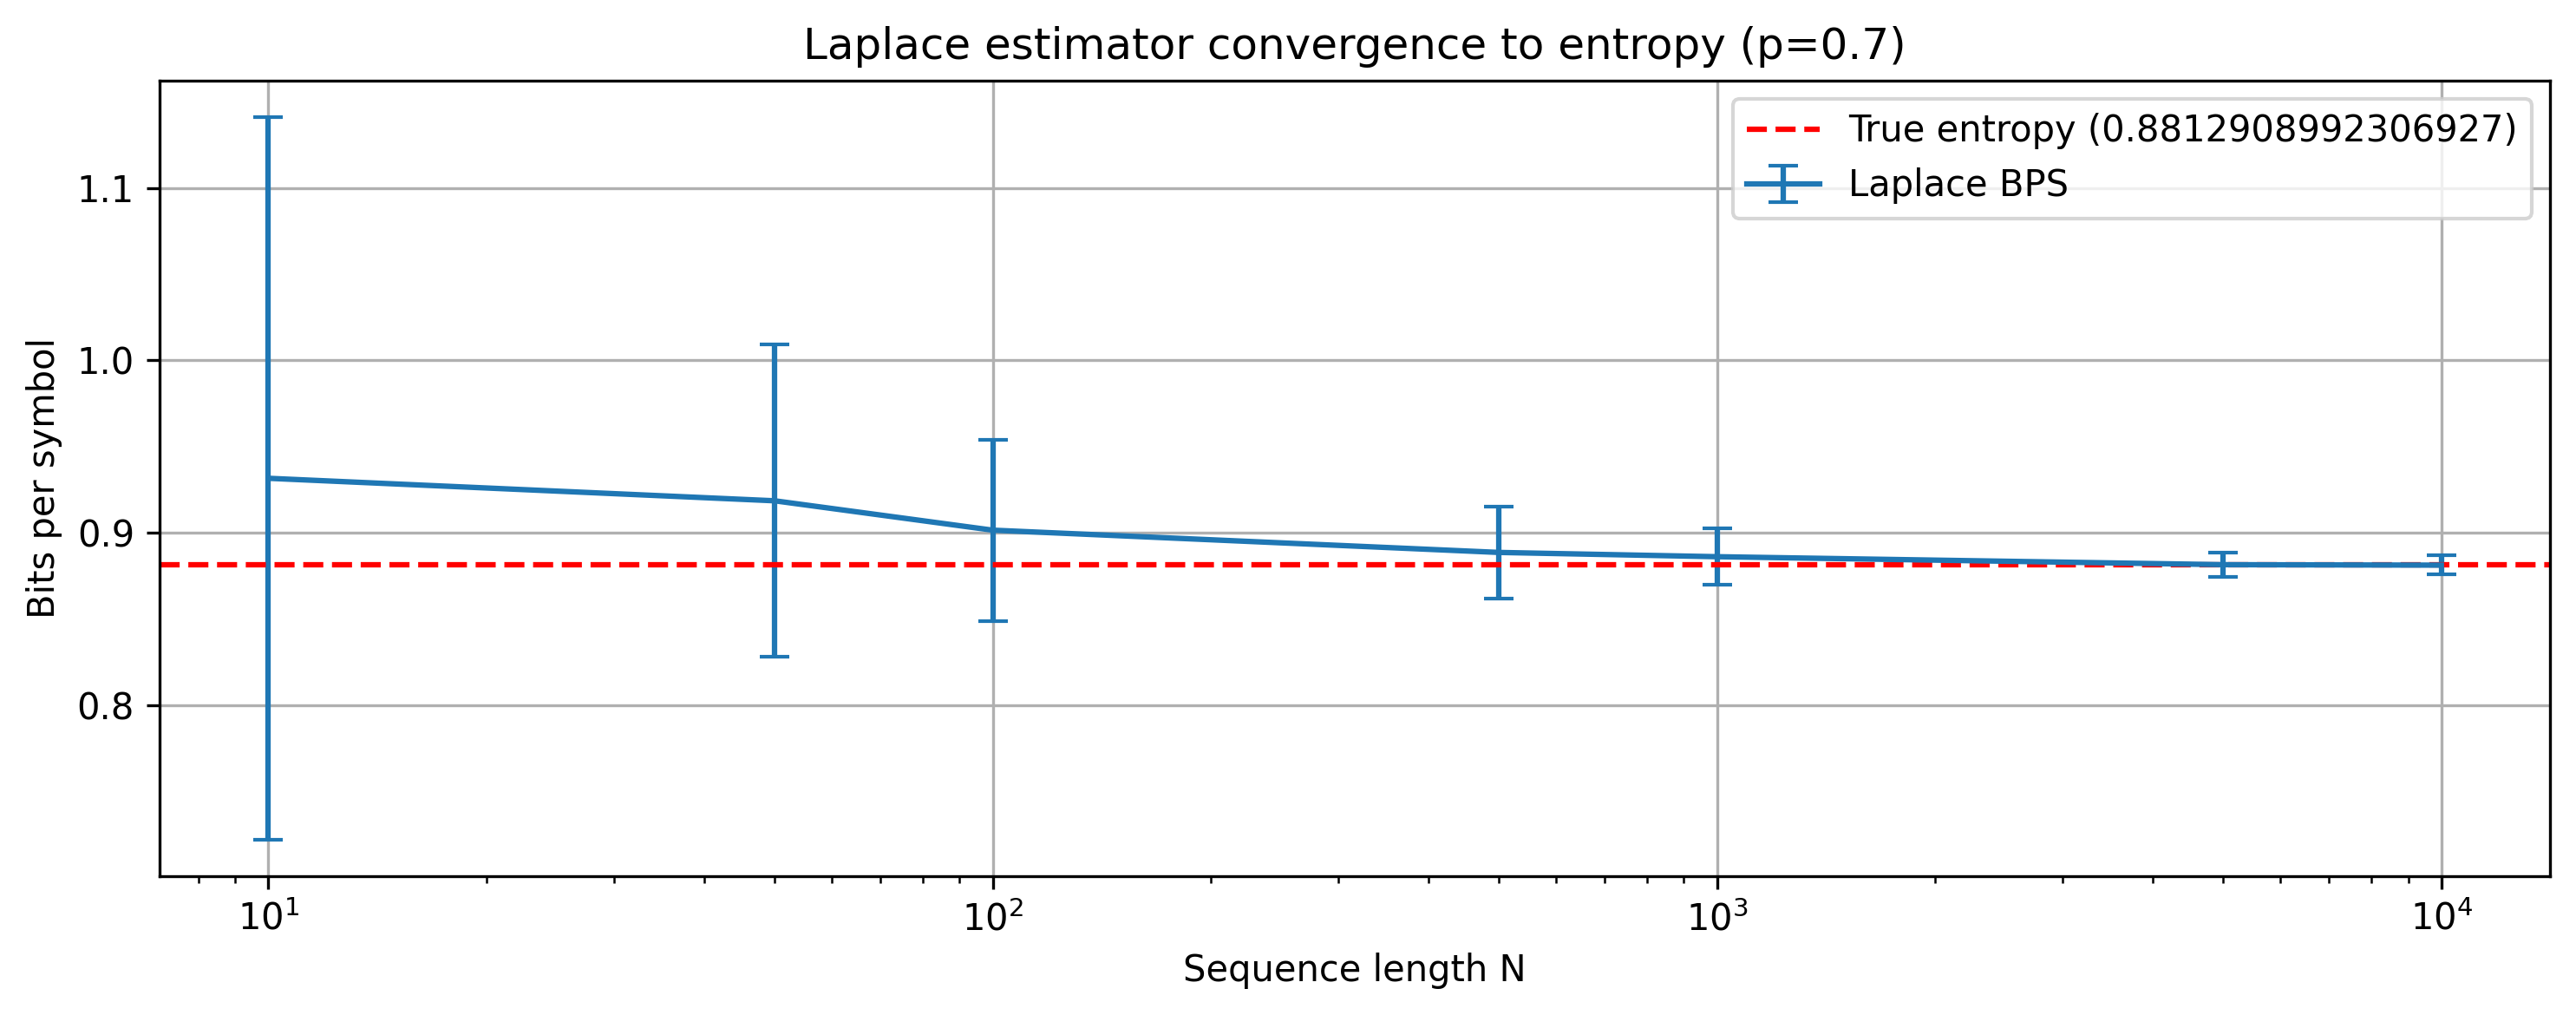

In [30]:
def bps_vs_N_sweep(p_true, N_values, n_trials=100):
    results = {}
    for N in N_values:
        trial_bps = []
        for _ in range(n_trials):
            seq = iid_generate({0: p_true, 1: 1-p_true}, N)
            trial_bps.append(sequential_universal_source_coding(seq))
        results[N] = (np.mean(trial_bps), np.std(trial_bps))
    return results

N_values = [10, 50, 100, 500, 1000, 5000, 10000]
p_true = 0.7
results = bps_vs_N_sweep(p_true, N_values, n_trials=100)

# unpack properly
means = [results[N][0] for N in N_values]
stds = [results[N][1] for N in N_values]
true_entropy = entropy_calc({0: p_true, 1: 1-p_true})

print(f"True entropy: {true_entropy}")
for N, m, s in zip(N_values, means, stds):
    print(f"N={N}  mean={m}  std={s}  gap={m-true_entropy}")

# plot
plt.figure(figsize=(10, 4), dpi=300)
plt.errorbar(N_values, means, yerr=stds, capsize=4, label='Laplace BPS')
plt.axhline(y=true_entropy, color='red', linestyle='--', label=f'True entropy ({true_entropy})')
plt.xscale('log')
plt.xlabel('Sequence length N')
plt.ylabel('Bits per symbol')
plt.title(f'Laplace estimator convergence to entropy (p={p_true})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

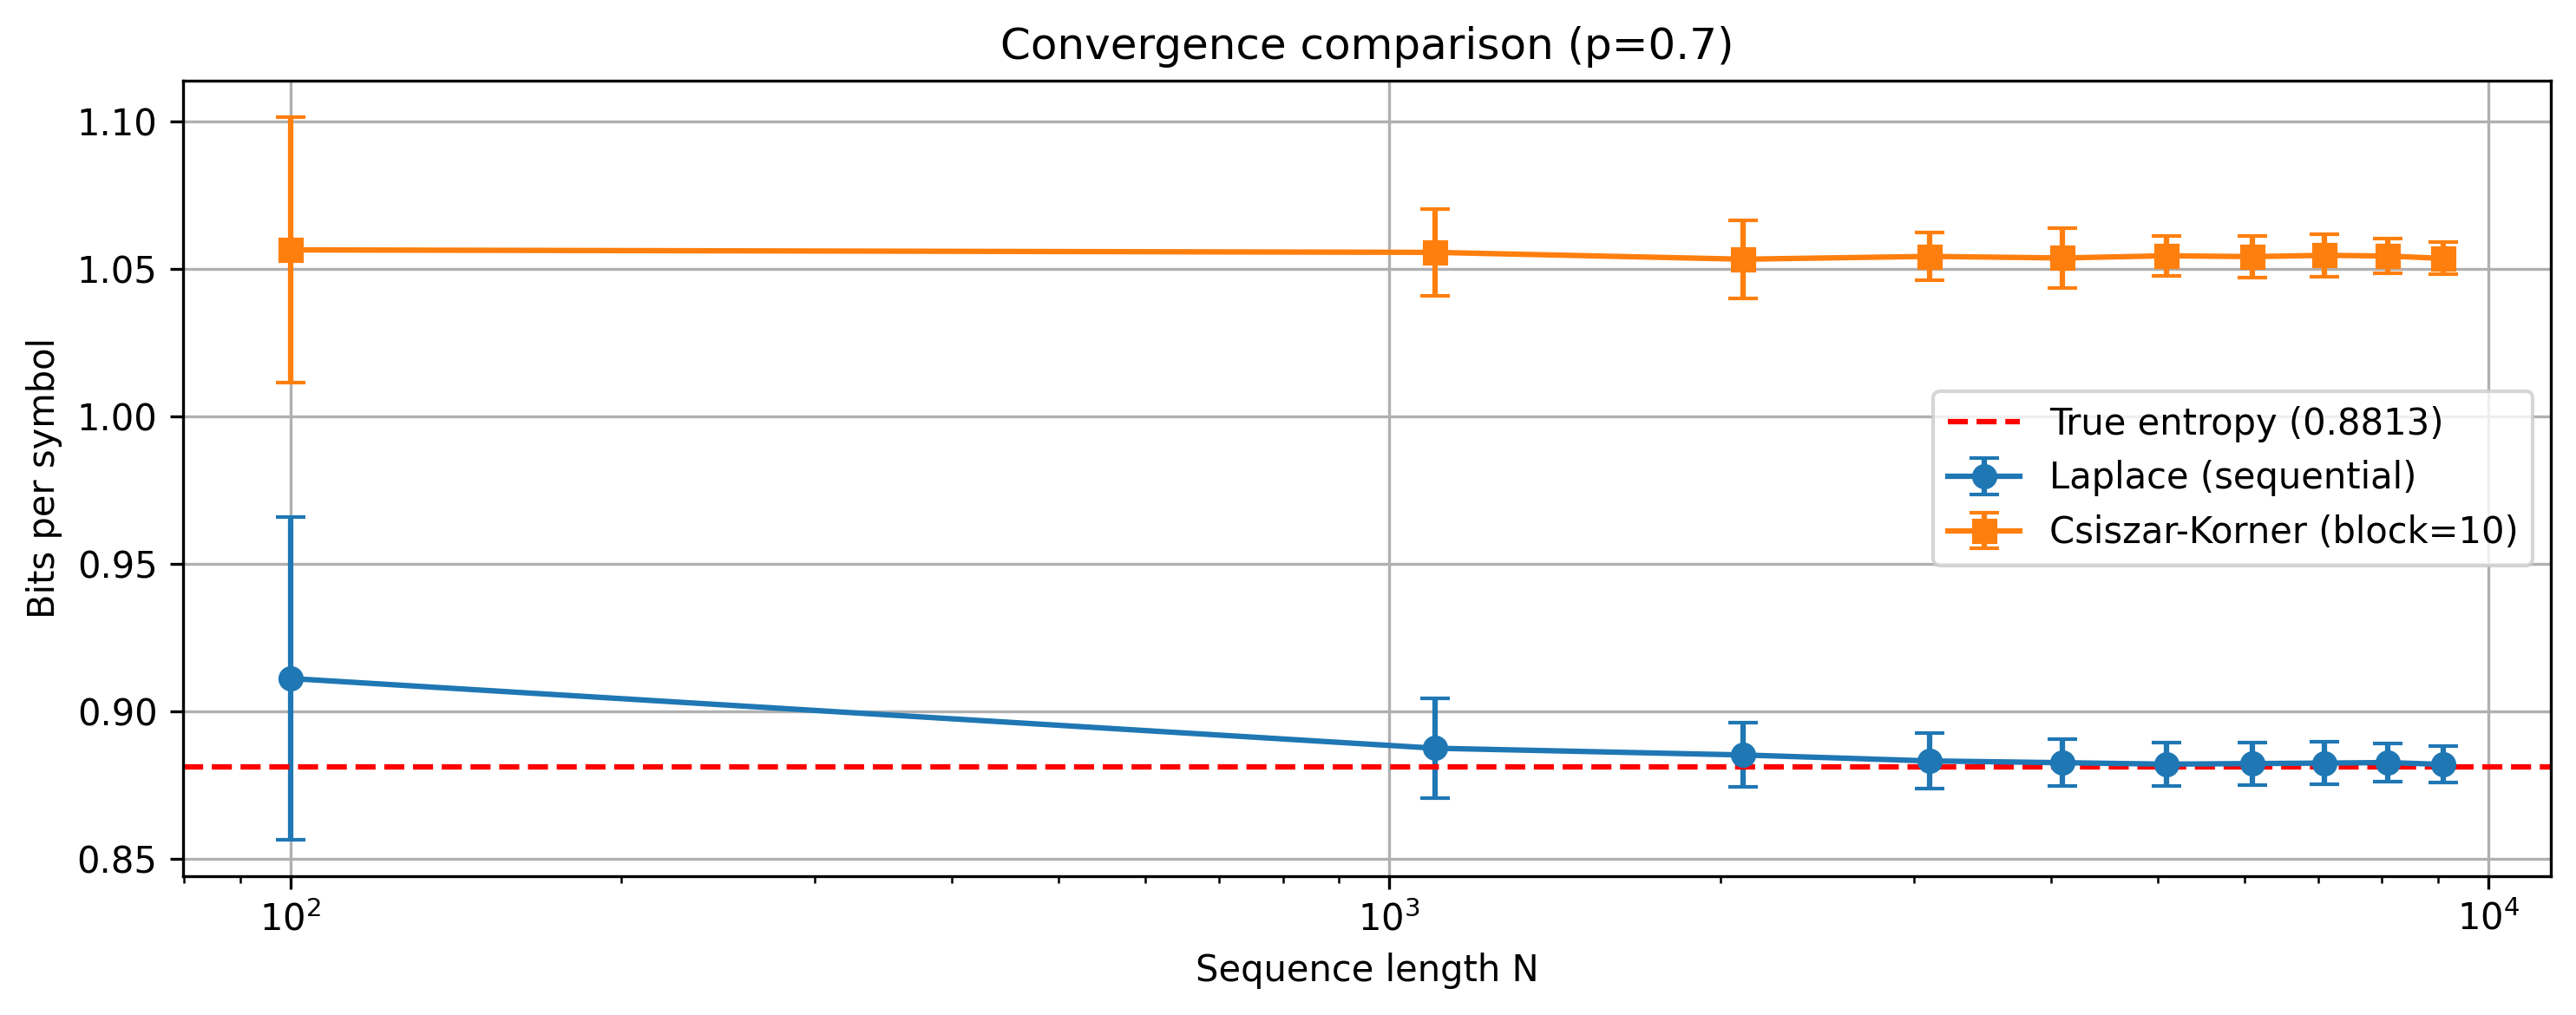

In [31]:
def bps_vs_N_sweep_ck(p_true, N_values, block_size, n_trials=100):
    results = {}
    for N in N_values:
        trial_bps = []
        for _ in range(n_trials):
            seq = list(iid_generate({0: p_true, 1: 1-p_true}, N))
            trial_bps.append(expected_ck(np.array(seq), block_size))
        results[N] = (np.mean(trial_bps), np.std(trial_bps))
    return results

# run both sweeps
#N_values = [100, 500, 1000, 5000, 10000]
N_values = np.arange(100, 10000, 1000)
p_true = 0.7
block_size = 10
true_entropy = entropy_calc({0: p_true, 1: 1-p_true})

results_laplace = bps_vs_N_sweep(p_true, N_values, n_trials=100)
results_ck = bps_vs_N_sweep_ck(p_true, N_values, block_size, n_trials=100)

means_laplace = [results_laplace[N][0] for N in N_values]
stds_laplace = [results_laplace[N][1] for N in N_values]
means_ck = [results_ck[N][0] for N in N_values]
stds_ck = [results_ck[N][1] for N in N_values]

plt.figure(figsize=(10, 4), dpi=300)
plt.errorbar(N_values, means_laplace, yerr=stds_laplace, fmt='o-', capsize=4, label='Laplace (sequential)')
plt.errorbar(N_values, means_ck, yerr=stds_ck, fmt='s-', capsize=4, label=f'Csiszar-Korner (block={block_size})')
plt.axhline(y=true_entropy, color='red', linestyle='--', label=f'True entropy ({true_entropy:.4f})')
plt.xscale('log')
plt.xlabel('Sequence length N')
plt.ylabel('Bits per symbol')
plt.title(f'Convergence comparison (p={p_true})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## minGPT

Here we start getting into minGPT. We will perform basic setup and run a few experiments. 

We formulate a hypothesis:
Laplace estimation for binary IID data approaches entropy as it sees more of a sequence. We hypothesize that this laplace estimation can be done offline by training the transformer to estimate "true p" that a laplace estimation scheme would produce. This offline learning can therefore produce gains for small n's, even for IID data that has no "structure to exploit"


In [ ]:

# We generate our dataset
import torch
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader
from mingpt.utils import set_seed

class IID(Dataset):
    """
    IID binary sequences 
    """

    def __init__(self, n=10, num_samples=10000):
        self.n = n
        self.num_samples = num_samples 

    def _sample(self):
        # sample probability p from uniform (0, 1)
        p = torch.rand(1).item()
        # generate IID Bernoulli sequence of length self.n
        seq = torch.bernoulli(torch.full((self.n,), p)).long()

        x = seq[:-1].clone()
        y = seq[1:].clone()

        return x, y

    def get_block_size(self):
        return self.n - 1

    def __getitem__(self, idx):
        return self._sample() 
    
    def __len__(self):
        return self.num_samples 

dataset = IID(n=100, num_samples=10000)


        



In [ ]:
from mingpt.model import GPT

model_config = GPT.get_default_config()
model_config.model_type = 'gpt-nano'
model_config.vocab_size = 2
model_config.block_size = dataset.get_block_size()
model = GPT(model_config)

In [ ]:
# create a Trainer object
from mingpt.trainer import Trainer

device = 'mps'
model = model.to(device)

train_config = Trainer.get_default_config()
train_config.learning_rate = 1e-4 # the model we're using is so small that we can go a bit faster
train_config.max_iters = 100000
train_config.num_workers = 0
trainer = Trainer(train_config, model, dataset)

In [ ]:
def batch_end_callback(trainer):
    if trainer.iter_num % 100 == 0:
        print(f"iter_dt {trainer.iter_num}; iter {trainer.iter_num}: train loss {trainer.loss.item():.5f}")
trainer.set_callback('on_batch_end', batch_end_callback)

#trainer.run()
#torch.save(model.state_dict(), 'iid_model.pt')

model.load_state_dict(torch.load('iid_model.pt'))

# Producing sequences

In this section we will develop our bit generation process and compute the bits/symbol metrics to compare compression schemes

In [11]:
import torch.nn.functional as F
from mingpt.model import GPT

model_config = GPT.get_default_config()
model_config.model_type = 'gpt-nano'
model_config.vocab_size = 2
model_config.block_size = 99

model = GPT(model_config)
model.load_state_dict(torch.load('iid_model.pt', map_location='cpu'))
model = model.to('mps')
model.eval()

# generate an array of probabilities given a bit sequence

def transformer_p_array(sequence, model, device='mps'):
    model.eval()
    sequence=torch.tensor(sequence, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        logits, _ = model(sequence)  # [1, T, vocab_size]
        # convert to probabilities
        probs = F.softmax(logits, dim=-1)  # [1, T, vocab_size]
        # extract probability of token=1 at each timestep
        p_array = probs[0, :, 1].tolist()  # list of floats
    
    return p_array



number of parameters: 0.09M


NameError: name 'torch' is not defined

In [ ]:

compress_seq = iid_generate(generate_bin_pmf(), 99)  # 99 because model block_size = n-1 = 99

bps_laplace = sequential_universal_source_coding(compress_seq)

p_array = transformer_p_array(compress_seq.tolist(), model)
p_array = [0.5] + p_array[:-1]  # assume first bit is uniform (no prior)
bps_transformer = sequential_universal_source_coding(compress_seq, p_array=p_array)

generated_p = convert_sample_to_pmf(compress_seq)
bps_entropy = entropy_calc(generated_p)

print(f'Entropy (lower bound): {bps_entropy:.4f}')
print(f'Laplace BPS:           {bps_laplace:.4f}')
print(f'Transformer BPS:       {bps_transformer:.4f}')

# Lets graph our stuff

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Transformer vs Laplace prior quality at small N

def transformer_p_array_windowed_fast(sequence, model, device='cpu'):
    """
    Generate probability estimates for each position using a sliding window.
    For each position i (1-indexed), feeds the model the last min(i, block_size) tokens
    and uses the output logit at the last position to predict the next token.
    """
    model.eval()
    B = model.block_size          # maximum context length the model can handle
    T = len(sequence)
    p_array = [0.5]                # prior for the first bit (no context)

    # Move sequence to the correct device once
    seq_tensor = torch.tensor(sequence, dtype=torch.long, device=device)

    with torch.no_grad():
        for i in range(1, T):
            # Context = tokens before position i, limited to the last B tokens
            start = max(0, i - B)
            context = seq_tensor[start:i].unsqueeze(0)  # shape [1, context_len]

            # Forward pass through the model
            logits, _ = model(context)                 # [1, context_len, vocab_size]
            # Take the logits from the last position (prediction for next token)
            next_token_logits = logits[0, -1, :]       # [vocab_size]
            probs = F.softmax(next_token_logits, dim=-1)
            p_next = probs[1].item()                    # probability of token 1
            p_array.append(p_next)

    return p_array

def run_experiment(model, p_values, N_values, n_trials=100, device='cpu'):
    """
    For each (p, N) pair, run n_trials with identical sequences for both methods.
    Returns nested dict: results[p][N] = {'laplace': (mean, std), 'transformer': (mean, std)}
    """
    all_results = {}

    for p_true in p_values:
        print(f"\nRunning p={p_true}")
        p_dict = {0: 1 - p_true, 1: p_true}
        all_results[p_true] = {}

        for N in N_values:
            laplace_bps_trials = []
            transformer_bps_trials = []

            for trial in range(n_trials):
                # Same sequence for both methods
                seq = iid_generate(p_dict, N)

                # Laplace
                bps_lap = sequential_universal_source_coding(seq)
                laplace_bps_trials.append(bps_lap)

                # Transformer
                p_array = transformer_p_array_windowed_fast(seq, model, device=device)
                bps_trans = sequential_universal_source_coding(seq, p_array=p_array)
                transformer_bps_trials.append(bps_trans)

            all_results[p_true][N] = {
                'laplace': (np.mean(laplace_bps_trials), np.std(laplace_bps_trials)),
                'transformer': (np.mean(transformer_bps_trials), np.std(transformer_bps_trials)),
                'entropy': -p_true * np.log2(p_true) - (1 - p_true) * np.log2(1 - p_true)
            }
            print(f"  N={N}: laplace={np.mean(laplace_bps_trials):.4f}, transformer={np.mean(transformer_bps_trials):.4f}")

    return all_results



In [ ]:

# Run!!
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
N_values = [10, 25, 50, 100, 200, 500]

all_results = run_experiment(model, p_values, N_values, n_trials=100, device='mps')

In [ ]:
#save stuff
import pickle

with open('iid_results_fixed.pkl', 'wb') as f:
    pickle.dump(all_results, f)


In [ ]:

def plot_bps_per_p(all_results, p_values, N_values, n_trials=100):
    n_plots = len(p_values)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), dpi=150)
    if n_plots == 1:
        axes = [axes]

    for ax, p_true in zip(axes, p_values):
        means_lap = [all_results[p_true][N]['laplace'][0] for N in N_values]
        stds_lap  = [all_results[p_true][N]['laplace'][1] for N in N_values]
        means_tr  = [all_results[p_true][N]['transformer'][0] for N in N_values]
        stds_tr   = [all_results[p_true][N]['transformer'][1] for N in N_values]
        entropy   = all_results[p_true][N_values[0]]['entropy']

        # convert to standard error
        se_lap = [s / np.sqrt(n_trials) for s in stds_lap]
        se_tr  = [s / np.sqrt(n_trials) for s in stds_tr]

        ax.errorbar(N_values, means_lap, yerr=se_lap, fmt='o-', capsize=4, label='Laplace')
        ax.errorbar(N_values, means_tr,  yerr=se_tr,  fmt='s-', capsize=4, label='Transformer')
        ax.axhline(y=entropy, color='red', linestyle='--', label=f'Entropy ({entropy:.3f})')
        penalty = 0.5 * np.log2(np.array(N_values)) / np.array(N_values)
        ax.plot(N_values, entropy + penalty, 'g--', label='Entropy + USC penalty', linewidth=1)
        ax.set_xscale('log')
        ax.set_title(f'p={p_true}')
        ax.set_xlabel('N')
        ax.set_ylabel('BPS')
        ax.legend(fontsize=7)
        ax.grid(True)

    plt.suptitle('Laplace vs Transformer BPS convergence', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_gap(all_results, p_values, N_values):
    """Plot the gap (laplace BPS - transformer BPS) per p. Positive = transformer wins."""
    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

    for p_true in p_values:
        gaps = [
            all_results[p_true][N]['laplace'][0] - all_results[p_true][N]['transformer'][0]
            for N in N_values
        ]
        ax.plot(N_values, gaps, marker='o', label=f'p={p_true}')

    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_xlabel('N')
    ax.set_ylabel('Laplace BPS - Transformer BPS')
    ax.set_title('Transformer advantage over Laplace (positive = transformer wins)')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


In [18]:
import torch
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader
from mingpt.utils import set_seed

class fixed_P(Dataset):
    """
    IID binary sequences 
    """

    def __init__(self, n=10, num_samples=10000):
        self.n = n
        self.num_samples = num_samples 

    def _sample(self):
        # sample probability p from uniform (0, 1)
        #p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
        p = 0.3
        # generate IID Bernoulli sequence of length self.n
        seq = torch.bernoulli(torch.full((self.n,), p)).long()

        x = seq[:-1].clone()
        y = seq[1:].clone()

        return x, y

    def get_block_size(self):
        return self.n - 1

    def __getitem__(self, idx):
        return self._sample() 
    
    def __len__(self):
        return self.num_samples 

dataset_fixed_p = fixed_P(n=100, num_samples=10000)

In [ ]:
# %%
# Define callback for training progress
def batch_end_callback(trainer):
    if trainer.iter_num % 100 == 0:
        print(f"iter_dt {trainer.iter_num}; iter {trainer.iter_num}: train loss {trainer.loss.item():.5f}")

In [19]:

# %%
# Recreate model config for the fixed-p model
from mingpt.model import GPT
from mingpt.trainer import Trainer

model_config = GPT.get_default_config()
model_config.model_type = 'gpt-nano'
model_config.vocab_size = 2
model_config.block_size = dataset_fixed_p.get_block_size()
device = 'mps'
model_fixed_p = GPT(model_config)
model_fixed_p = model_fixed_p.to(device)

# %%
# Setup trainer for fixed-p model
train_config = Trainer.get_default_config()
train_config.learning_rate = 1e-4
train_config.max_iters = 1000
train_config.num_workers = 0
train_config.device = device


trainer_fixed_p = Trainer(train_config, model_fixed_p, dataset_fixed_p)

# Add callback
trainer_fixed_p.set_callback('on_batch_end', batch_end_callback)

# Train!
trainer_fixed_p.run()

# Save the trained model
torch.save(model_fixed_p.state_dict(), 'p3_model.pt')
print("Training complete! Model saved to 'iid_model_p07.pt'")
# Load with explicit device mapping
'''


'''


number of parameters: 0.09M
running on device mps


NameError: name 'batch_end_callback' is not defined

In [ ]:
state_dict = torch.load('p3_model.pt', map_location='cpu')  # Load to CPU first
model_fixed_p.load_state_dict(state_dict)
model_fixed_p = model_fixed_p.to(device)
model_fixed_p.eval()
print(f'loaded! Model device: {next(model_fixed_p.parameters()).device}')

In [20]:
p_values = [0.3]
N_values = [10, 25, 50, 100, 200, 500]


p7_experiment_results = run_experiment(model_fixed_p, p_values, N_values, n_trials=100, device='mps')


Running p=0.3


KeyboardInterrupt: 

In [13]:
import pickle
with open('p7_results_fixed.pkl', 'rb') as f:
    p7_results_fixed = pickle.load(f)
print(p7_results_fixed)

{0.7: {10: {'laplace': (np.float64(0.9718765576703483), np.float64(0.14598422480312262)), 'transformer': (np.float64(0.8869818367888703), np.float64(0.16134283259654067)), 'entropy': np.float64(0.8812908992306927)}, 25: {'laplace': (np.float64(0.9449020721004062), np.float64(0.11169789292807485)), 'transformer': (np.float64(0.8895483958058098), np.float64(0.1123907652543899)), 'entropy': np.float64(0.8812908992306927)}, 50: {'laplace': (np.float64(0.9163807327513684), np.float64(0.07489817846188696)), 'transformer': (np.float64(0.8772328368213297), np.float64(0.07619637900212956)), 'entropy': np.float64(0.8812908992306927)}, 100: {'laplace': (np.float64(0.9060822474650659), np.float64(0.06015932260434652)), 'transformer': (np.float64(0.882877311884619), np.float64(0.06064020876406023)), 'entropy': np.float64(0.8812908992306927)}, 200: {'laplace': (np.float64(0.8956453493142864), np.float64(0.042647068198004165)), 'transformer': (np.float64(0.8822872264714324), np.float64(0.041799806752

In [21]:
import pickle
with open('iid_results_fixed.pkl', 'rb') as f:
    iid_results = pickle.load(f)
print(iid_results)

{0.1: {10: {'laplace': (np.float64(0.677239614544102), np.float64(0.21349451757391452)), 'transformer': (np.float64(0.6892776753150828), np.float64(0.21477467984875173)), 'entropy': np.float64(0.4689955935892812)}, 25: {'laplace': (np.float64(0.5385125463021749), np.float64(0.16628744122485858)), 'transformer': (np.float64(0.5469522893563713), np.float64(0.16510249155942167)), 'entropy': np.float64(0.4689955935892812)}, 50: {'laplace': (np.float64(0.5220160238964363), np.float64(0.11544534139651727)), 'transformer': (np.float64(0.5253384915877928), np.float64(0.11398305932083536)), 'entropy': np.float64(0.4689955935892812)}, 100: {'laplace': (np.float64(0.5017913865413539), np.float64(0.0884183481866983)), 'transformer': (np.float64(0.5028003042755134), np.float64(0.08826808650865887)), 'entropy': np.float64(0.4689955935892812)}, 200: {'laplace': (np.float64(0.4831428237172666), np.float64(0.06584423806508115)), 'transformer': (np.float64(0.48508629278478305), np.float64(0.066733461072

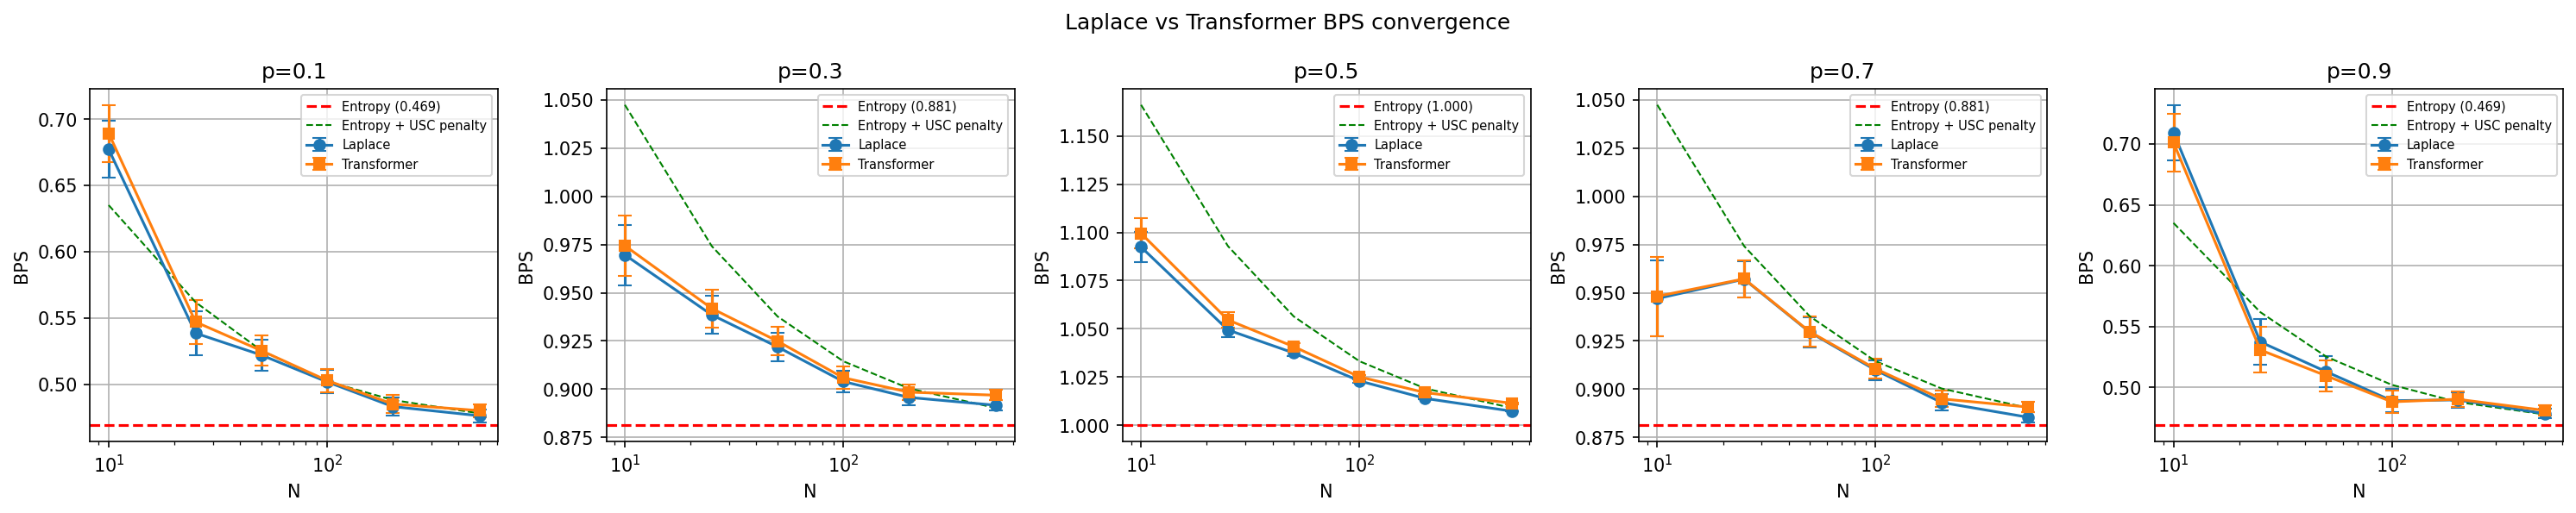

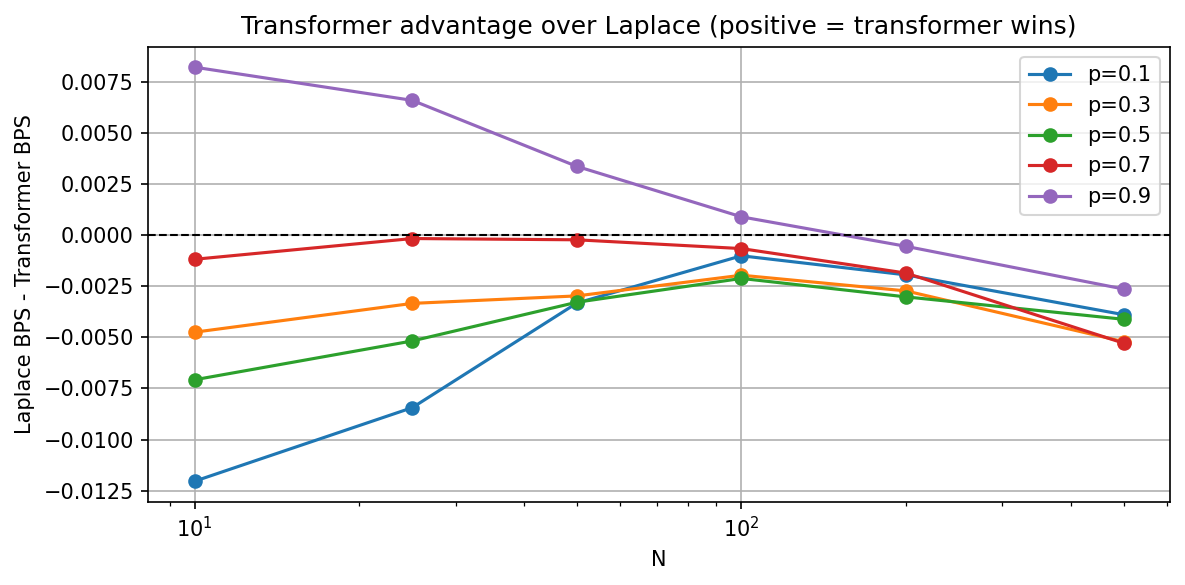

In [5]:
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
N_values = [10, 25, 50, 100, 200, 500]
plot_bps_per_p(iid_results, p_values, N_values)
plot_gap(iid_results, p_values, N_values)

In [6]:

import pickle
with open('p3_results_fixed.pkl', 'rb') as f:
    p3_results = pickle.load(f)
print(p3_results)

{0.3: {10: {'laplace': (np.float64(0.9591331658070229), np.float64(0.17074597251260112)), 'transformer': (np.float64(0.8832127031193262), np.float64(0.17312307631196636)), 'entropy': np.float64(0.8812908992306927)}, 25: {'laplace': (np.float64(0.9378256042123856), np.float64(0.11449965313689735)), 'transformer': (np.float64(0.8856638982654685), np.float64(0.12050897558621303)), 'entropy': np.float64(0.8812908992306927)}, 50: {'laplace': (np.float64(0.9320273814644865), np.float64(0.07359720399100105)), 'transformer': (np.float64(0.8963953126610948), np.float64(0.07973242581479309)), 'entropy': np.float64(0.8812908992306927)}, 100: {'laplace': (np.float64(0.904965246605384), np.float64(0.05724035302480695)), 'transformer': (np.float64(0.882127941714645), np.float64(0.059457800176591726)), 'entropy': np.float64(0.8812908992306927)}, 200: {'laplace': (np.float64(0.8929383310240196), np.float64(0.03468726199120816)), 'transformer': (np.float64(0.8784807288492712), np.float64(0.037758961098

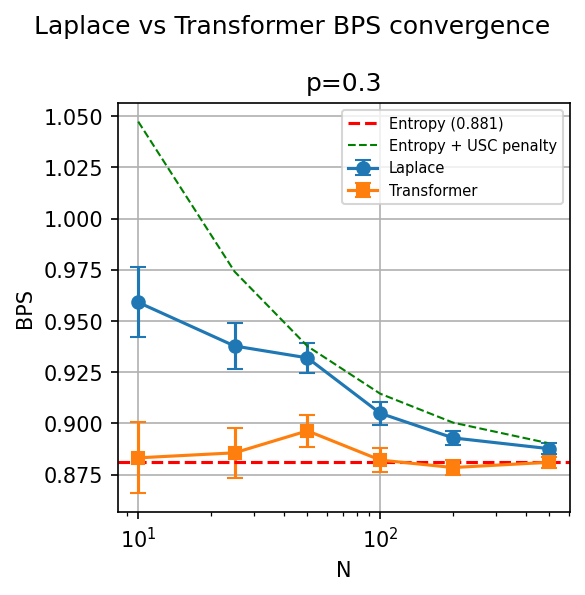

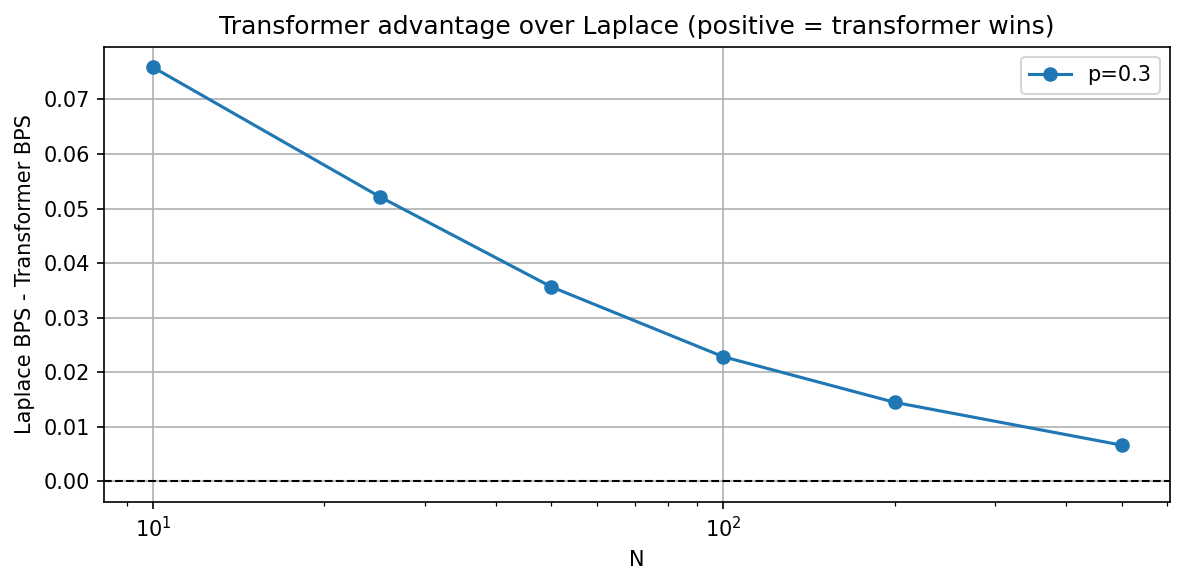

In [7]:

p_values = [0.3]
N_values = [10, 25, 50, 100, 200, 500]
plot_bps_per_p(p3_results, p_values, N_values)
plot_gap(p3_results, p_values, N_values)

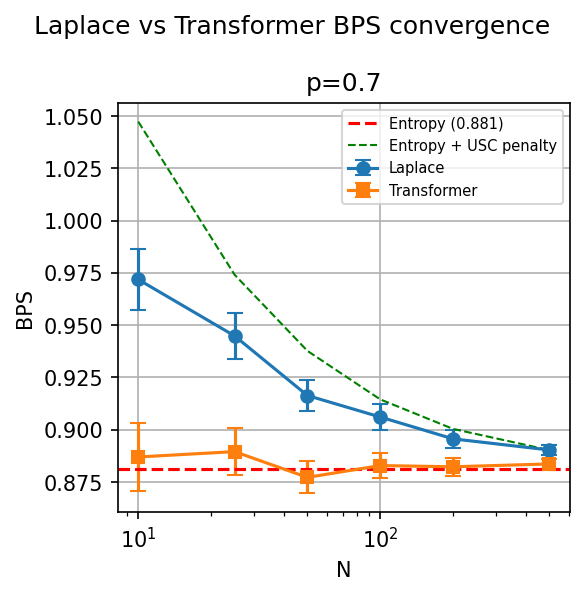

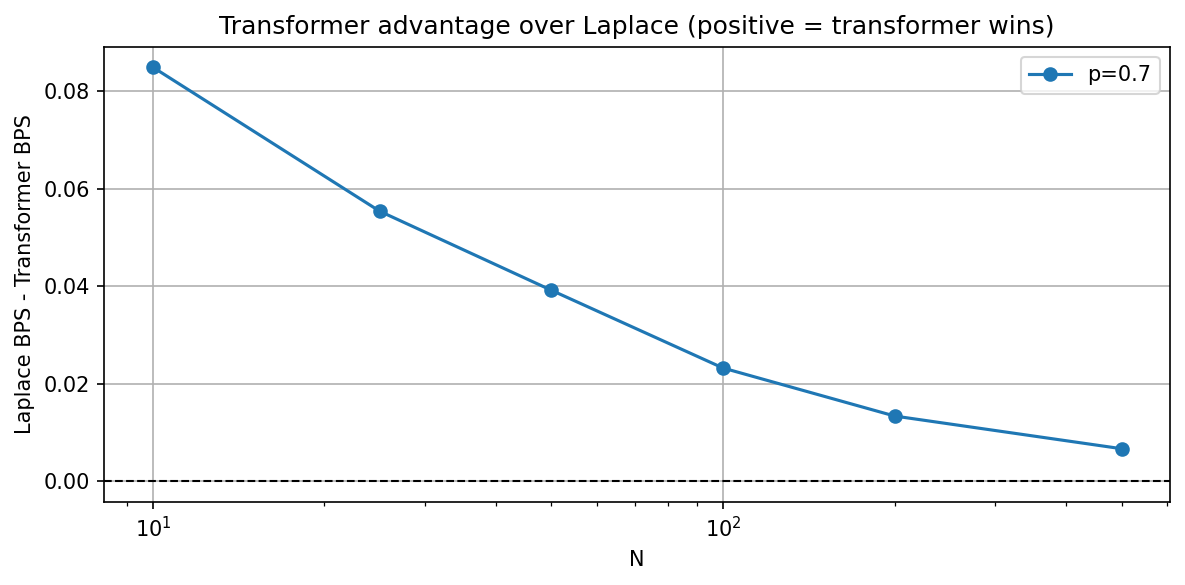

In [8]:
p_values = [0.7]
N_values = [10, 25, 50, 100, 200, 500]
plot_bps_per_p(p7_results_fixed, p_values, N_values)
plot_gap(p7_results_fixed, p_values, N_values)

In [22]:

#save stuff
import pickle

with open('p3_results_fixed.pkl', 'wb') as f:
    pickle.dump(p7_experiment_results, f)

NameError: name 'p7_experiment_results' is not defined

In [9]:
with open('p3_results_fixed.pkl', 'rb') as f:
    p3_results = pickle.load(f)
print(p3_results)

{0.3: {10: {'laplace': (np.float64(0.9591331658070229), np.float64(0.17074597251260112)), 'transformer': (np.float64(0.8832127031193262), np.float64(0.17312307631196636)), 'entropy': np.float64(0.8812908992306927)}, 25: {'laplace': (np.float64(0.9378256042123856), np.float64(0.11449965313689735)), 'transformer': (np.float64(0.8856638982654685), np.float64(0.12050897558621303)), 'entropy': np.float64(0.8812908992306927)}, 50: {'laplace': (np.float64(0.9320273814644865), np.float64(0.07359720399100105)), 'transformer': (np.float64(0.8963953126610948), np.float64(0.07973242581479309)), 'entropy': np.float64(0.8812908992306927)}, 100: {'laplace': (np.float64(0.904965246605384), np.float64(0.05724035302480695)), 'transformer': (np.float64(0.882127941714645), np.float64(0.059457800176591726)), 'entropy': np.float64(0.8812908992306927)}, 200: {'laplace': (np.float64(0.8929383310240196), np.float64(0.03468726199120816)), 'transformer': (np.float64(0.8784807288492712), np.float64(0.037758961098

In [23]:

p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
N_values = [10, 25, 50, 100, 200, 500]


p_experiment_results = run_experiment(model_fixed_p, p_values, N_values, n_trials=100, device='mps')


Running p=0.1


KeyboardInterrupt: 

In [27]:

#save stuff
import pickle

with open('p_results_fixed.pkl', 'wb') as f:
    pickle.dump(p_experiment_results, f)

NameError: name 'p_experiment_results' is not defined

In [26]:

import pickle

with open('p_results_fixed.pkl', 'rb') as f:
    p_results_fixed = pickle.load(f)
print(p_results_fixed)


EOFError: Ran out of input

In [25]:

p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
N_values = [10, 25, 50, 100, 200, 500]
plot_bps_per_p(p_results_fixed, p_values, N_values)
plot_gap(p_results_fixed, p_values, N_values)

NameError: name 'plot_bps_per_p' is not defined